# Tiny Reasoner — Full Evaluation Notebook

This notebook:
1. Clones the repo and installs dependencies
2. Downloads checkpoints from Google Drive
3. Evaluates each model on GSM8K test set
4. Produces comparison tables and plots
5. Shows example generations from each method

## 1. Setup

In [ ]:
# Clone repo and install dependencies
!git clone https://github.com/yuliya1324/Tiny_Reasoner.git
%cd Tiny_Reasoner
!pip install -q -r requirements.txt
!pip install -q gdown  # for Google Drive downloads

In [ ]:
import gdown
import os

CHECKPOINT_ZIPS = {
    "sft_baseline": "1aS_yjWZPtpAThFpLXiZJFaWNvynLf8K1",
    "dpo":          "157t6ID5-_1qoeMl2njt3L3Fe7ymhAktD",
    "ppo":          "1W6mqW28lsQeVoDNJYaT_riLwv5ckv0yG",
    "grpo":         "1pMPtcCH5WMHseWOSRvfK5ws03GQtsAa4"
}
CHECKPOINTS_DIR = "/Data/iuliia.korotkova/RL/checkpoints"

for name, file_id in CHECKPOINT_ZIPS.items():
    output_path = f"{CHECKPOINTS_DIR}/{name}.zip"
    if not os.path.exists(output_path):
        try:
            gdown.download(id=file_id, output=output_path, quiet=False)
            !unzip -q {output_path} -d {CHECKPOINTS_DIR}/{name}
        except Exception as e:
            print(f"  Skipping {name}: {e}")

In [ ]:
# ============================================================
# We propose to run evaluation only on four models:
# one from each method which showed the best results.
# This is just to save the time, but feel free to check all models in all variants.
# ============================================================

MODELS = [
    ("SFT Baseline",              "—",              "—",    f"{CHECKPOINTS_DIR}/sft_baseline/final"),
    # ("DPO (GT&SFT)",              "Preference",     "SFT",  f"{CHECKPOINTS_DIR}/dpo/DPO/dpo_gt_sft"),
    # ("DPO (GT&Syn)",              "Preference",     "SFT",  f"{CHECKPOINTS_DIR}/dpo/DPO/dpo_gt_syn"),
    # ("DPO (Short&SFT)",           "Preference",     "SFT",  f"{CHECKPOINTS_DIR}/dpo/DPO/dpo_short_sft"),
    ("DPO (Short&Syn)",           "Preference",     "SFT",  f"{CHECKPOINTS_DIR}/dpo/DPO/dpo_short_sft"),
    # ("PPO (sparse)",              "Sparse",         "SFT",  f"{CHECKPOINTS_DIR}/ppo/PPO/sparse"),
    # ("PPO (format)",              "Format-shaped",  "SFT",  f"{CHECKPOINTS_DIR}/ppo/PPO/format_shaped"),
    ("PPO (token-level)",         "Token-level",    "SFT",  f"{CHECKPOINTS_DIR}/ppo/PPO/intermediate_rewards"),
    ("GRPO (sparse)",             "Sparse",         "Base", f"{CHECKPOINTS_DIR}/grpo/GRPO/grpo/final"),
    # ("GRPO (sparse, SFT init)",   "Sparse",         "SFT",  f"{CHECKPOINTS_DIR}/grpo/GRPO/grpo_from_sft/final"),
    # ("GRPO (format)",             "Format-shaped",  "Base", f"{CHECKPOINTS_DIR}/grpo/GRPO/grpo_format/checkpoint-934"),
    # ("GRPO (format, SFT init)",   "Format-shaped",  "SFT",  f"{CHECKPOINTS_DIR}/grpo/GRPO/grpo_format_from_sft/final"),
    # ("GRPO (composite)",          "Composite",      "Base", f"{CHECKPOINTS_DIR}/grpo/GRPO/grpo_composite/final"),
    # ("GRPO (composite, SFT init)","Composite",      "SFT",  f"{CHECKPOINTS_DIR}/grpo/GRPO/grpo_composite_from_sft/final"),
]

# Filter to only existing checkpoints
MODELS = [(n, r, i, p) for n, r, i, p in MODELS if os.path.exists(p)]
print(f"Found {len(MODELS)} checkpoints:")
for name, _, _, path in MODELS:
    print(f"  {name}: {path}")

## 2. Evaluate All Models

In [ ]:
import yaml
import torch
import gc
from src.models.loader import load_model_from_checkpoint
from src.evaluation.evaluate import evaluate_model

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

all_results = {}  # name -> {"metrics": ..., "results": ...}

for name, reward, init, checkpoint_path in MODELS:
    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print(f"{'='*60}")

    model, tokenizer = load_model_from_checkpoint(checkpoint_path, cfg)
    eval_output = evaluate_model(model, tokenizer, split="test", batch_size=16)

    all_results[name] = {
        "reward": reward,
        "init": init,
        "metrics": eval_output["metrics"],
        "results": eval_output["results"],
    }

    # Print metrics
    for k, v in eval_output["metrics"].items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

    # Free GPU memory before loading next model
    del model
    gc.collect()
    torch.cuda.empty_cache()

print(f"\nDone! Evaluated {len(all_results)} models.")

## 3. Results Table

In [21]:
import pandas as pd

rows = []
for name, data in all_results.items():
    m = data["metrics"]
    rows.append({
        "Method": name,
        "Reward": data["reward"],
        "Init": data["init"],
        "Accuracy": m["accuracy"],
        "Format Adh.": m["format_adherence"],
        "Has Reasoning": m["has_reasoning"],
        "Avg Reas. Len": m["avg_reasoning_length"],
    })

df = pd.DataFrame(rows)
df = df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

# Display with formatting
styled = df.style.format({
    "Accuracy": "{:.3f}",
    "Format Adh.": "{:.3f}",
    "Has Reasoning": "{:.3f}",
    "Avg Reas. Len": "{:.1f}",
}).background_gradient(subset=["Accuracy"], cmap="YlGn")

styled

,Method,Reward,Init,Accuracy,Format Adh.,Has Reasoning,Avg Reas. Len
0,GRPO (sparse),Sparse,Base,0.474,0.000,0.000,0.0
1,SFT Baseline,—,—,0.298,0.999,0.999,46.4
2,DPO (Short&Syn),Preference,SFT,0.283,0.996,0.993,41.8
3,PPO (token-level),Token-level,SFT,0.213,0.999,0.998,35.7


## 4. Plots

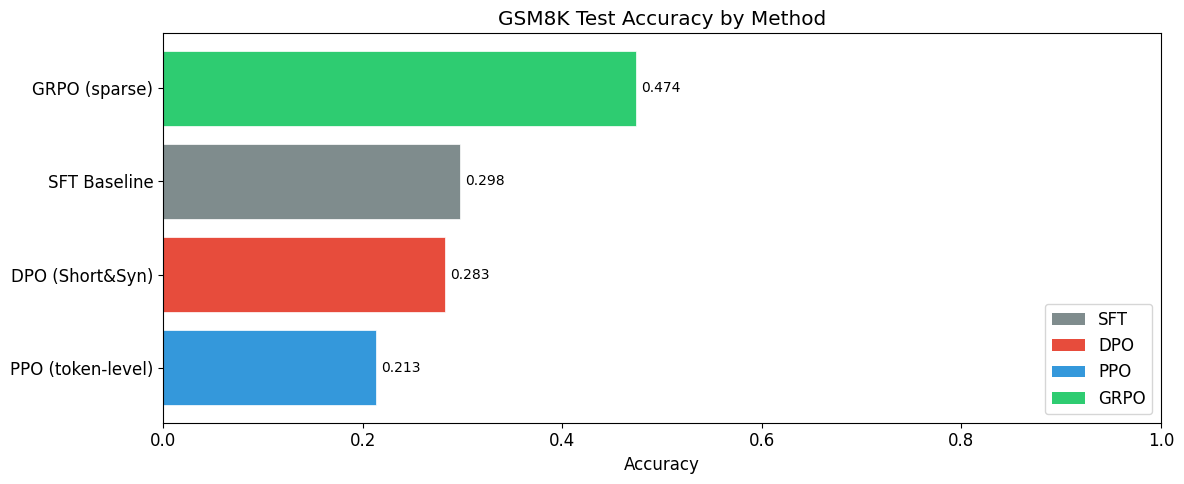

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({"font.size": 12})

# --- Plot 1: Accuracy comparison ---
fig, ax = plt.subplots(figsize=(12, 5))
colors = []
for name in df["Method"]:
    if "SFT" in name and "GRPO" not in name and "PPO" not in name:
        colors.append("#7f8c8d")
    elif "DPO" in name:
        colors.append("#e74c3c")
    elif "PPO" in name:
        colors.append("#3498db")
    elif "GRPO" in name:
        colors.append("#2ecc71")
    else:
        colors.append("#95a5a6")

bars = ax.barh(df["Method"], df["Accuracy"], color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Accuracy")
ax.set_title("GSM8K Test Accuracy by Method")
ax.set_xlim(0, 1)
ax.invert_yaxis()

for bar, val in zip(bars, df["Accuracy"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#7f8c8d", label="SFT"),
    Patch(facecolor="#e74c3c", label="DPO"),
    Patch(facecolor="#3498db", label="PPO"),
    Patch(facecolor="#2ecc71", label="GRPO"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

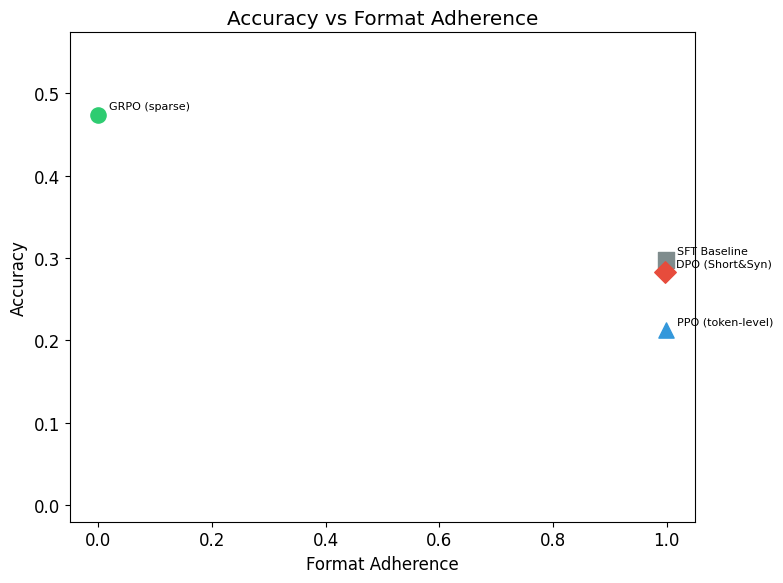

In [24]:
# --- Plot 2: Accuracy vs Format Adherence scatterplot ---
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in df.iterrows():
    name = row["Method"]
    if "SFT" in name and "GRPO" not in name and "PPO" not in name:
        c, m = "#7f8c8d", "s"
    elif "DPO" in name:
        c, m = "#e74c3c", "D"
    elif "PPO" in name:
        c, m = "#3498db", "^"
    elif "GRPO" in name:
        c, m = "#2ecc71", "o"
    else:
        c, m = "#95a5a6", "x"
    ax.scatter(row["Format Adh."], row["Accuracy"], c=c, marker=m, s=120, zorder=5)
    ax.annotate(name, (row["Format Adh."], row["Accuracy"]),
                textcoords="offset points", xytext=(8, 4), fontsize=8)

ax.set_xlabel("Format Adherence")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Format Adherence")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.02, min(1.0, df["Accuracy"].max() + 0.1))

plt.tight_layout()
plt.savefig("accuracy_vs_format.png", dpi=150, bbox_inches="tight")
plt.show()

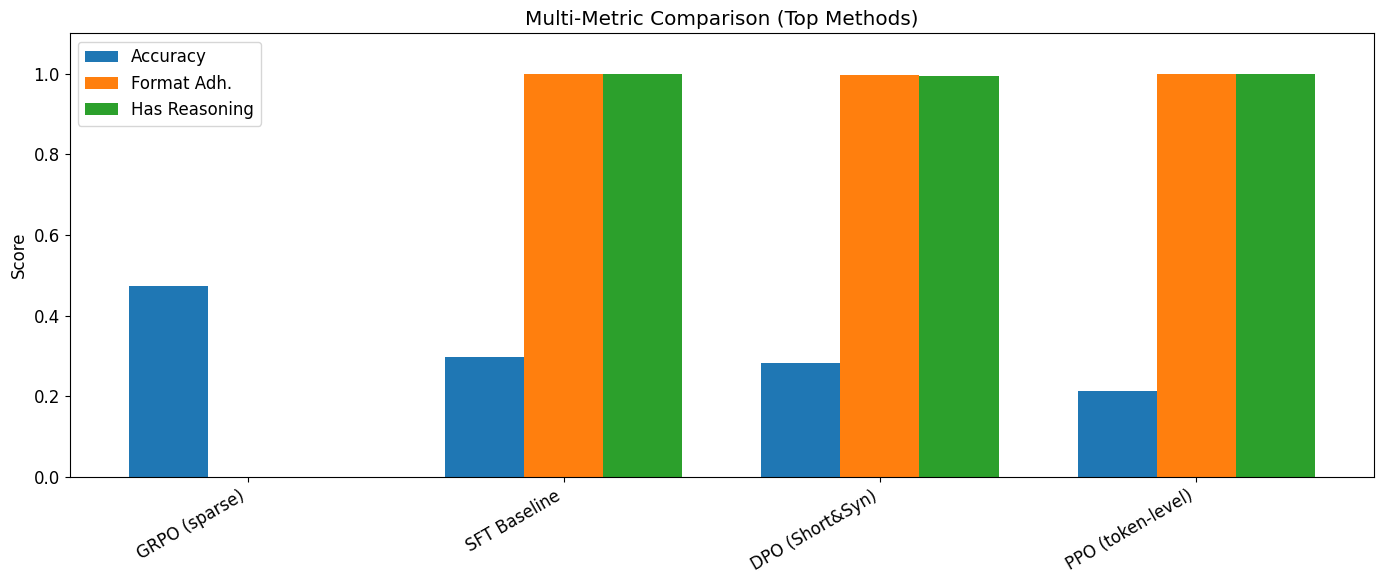

In [25]:
# --- Plot 3: Multi-metric grouped bar chart (top methods only) ---
metrics_to_plot = ["Accuracy", "Format Adh.", "Has Reasoning"]
top_df = df.head(8)  # top 8 by accuracy

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top_df))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, top_df[metric], width, label=metric)

ax.set_ylabel("Score")
ax.set_title("Multi-Metric Comparison (Top Methods)")
ax.set_xticks(x + width)
ax.set_xticklabels(top_df["Method"], rotation=30, ha="right")
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig("multi_metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

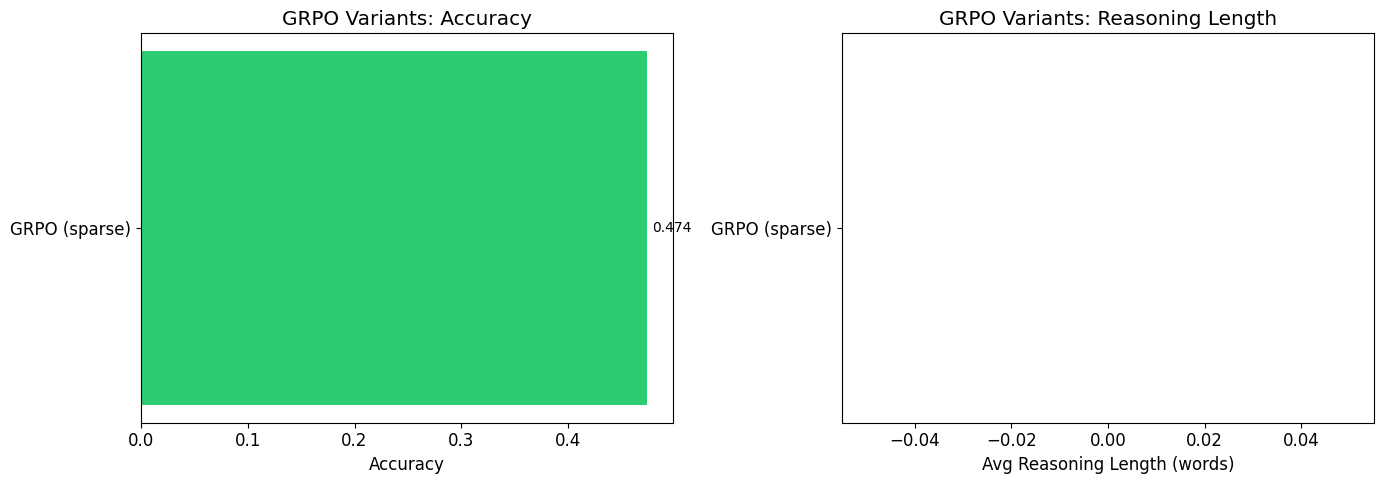

In [26]:
# --- Plot 4: GRPO reward shaping ablation ---
grpo_rows = df[df["Method"].str.contains("GRPO")].copy()

if len(grpo_rows) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Accuracy
    axes[0].barh(grpo_rows["Method"], grpo_rows["Accuracy"], color="#2ecc71")
    axes[0].set_xlabel("Accuracy")
    axes[0].set_title("GRPO Variants: Accuracy")
    axes[0].invert_yaxis()
    for i, val in enumerate(grpo_rows["Accuracy"]):
        axes[0].text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=10)

    # Right: Avg Reasoning Length
    axes[1].barh(grpo_rows["Method"], grpo_rows["Avg Reas. Len"], color="#27ae60")
    axes[1].set_xlabel("Avg Reasoning Length (words)")
    axes[1].set_title("GRPO Variants: Reasoning Length")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig("grpo_ablation.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5. Example Generations

Show 3 examples per model: one easy (correct), one hard (incorrect), and one random.

In [27]:
from IPython.display import display, HTML

def show_examples(name, results, n_correct=2, n_incorrect=2):
    """Display a few correct and incorrect examples from a model."""
    correct = [r for r in results if r["correct"]]
    incorrect = [r for r in results if not r["correct"]]

    html = f"<h3>{name}</h3>"

    # Show correct examples
    html += "<h4 style='color: green;'>Correct Examples</h4>"
    for r in correct[:n_correct]:
        response_escaped = r['response'].replace('<', '&lt;').replace('>', '&gt;').replace('\n', '<br>')
        html += f"""
        <div style='border: 1px solid #27ae60; border-radius: 8px; padding: 12px; margin: 8px 0; background: #f0fff0;'>
            <b>Q:</b> {r['question']}<br>
            <b>Ground truth:</b> {r['ground_truth']}<br>
            <b>Model output:</b><br>
            <pre style='background: white; padding: 8px; border-radius: 4px; white-space: pre-wrap;'>{response_escaped}</pre>
            <b>Predicted:</b> {r['predicted_answer']} ✓
        </div>
        """

    # Show incorrect examples
    html += "<h4 style='color: red;'>Incorrect Examples</h4>"
    for r in incorrect[:n_incorrect]:
        response_escaped = r['response'].replace('<', '&lt;').replace('>', '&gt;').replace('\n', '<br>')
        html += f"""
        <div style='border: 1px solid #e74c3c; border-radius: 8px; padding: 12px; margin: 8px 0; background: #fff0f0;'>
            <b>Q:</b> {r['question']}<br>
            <b>Ground truth:</b> {r['ground_truth']}<br>
            <b>Model output:</b><br>
            <pre style='background: white; padding: 8px; border-radius: 4px; white-space: pre-wrap;'>{response_escaped}</pre>
            <b>Predicted:</b> {r['predicted_answer']} ✗
        </div>
        """

    display(HTML(html))

In [28]:
# Show examples for each model
for name, data in all_results.items():
    show_examples(name, data["results"])

## 6. Side-by-Side Comparison on Same Questions

Pick a few questions and show how different models answer them.

In [29]:
# Pick 5 questions where models disagree
model_names = list(all_results.keys())
if len(model_names) >= 2:
    n_examples = min(len(all_results[model_names[0]]["results"]), 1319)

    # Find questions where at least one model is correct and one is wrong
    interesting_indices = []
    for i in range(n_examples):
        correctness = [all_results[m]["results"][i]["correct"] for m in model_names]
        if any(correctness) and not all(correctness):
            interesting_indices.append(i)

    print(f"Found {len(interesting_indices)} questions where models disagree.")
    print("Showing first 5:\n")

    for idx in interesting_indices[:5]:
        q = all_results[model_names[0]]["results"][idx]["question"]
        gt = all_results[model_names[0]]["results"][idx]["ground_truth"]

        html = f"<div style='border: 2px solid #333; border-radius: 8px; padding: 12px; margin: 16px 0;'>"
        html += f"<b>Question:</b> {q}<br><b>Ground truth:</b> {gt}<br><hr>"

        for m in model_names:
            r = all_results[m]["results"][idx]
            status = "✓" if r["correct"] else "✗"
            color = "#27ae60" if r["correct"] else "#e74c3c"
            response_escaped = r['response'].replace('<', '&lt;').replace('>', '&gt;').replace('\n', '<br>')
            html += f"""
            <div style='margin: 4px 0;'>
                <b style='color: {color};'>{m} → {r['predicted_answer']} {status}</b><br>
                <details><summary>Show output</summary>
                <pre style='background: #f8f8f8; padding: 8px; border-radius: 4px; white-space: pre-wrap; font-size: 11px;'>{response_escaped}</pre>
                </details>
            </div>
            """

        html += "</div>"
        display(HTML(html))

Found 670 questions where models disagree.
Showing first 5:



## 7. Save All Results

In [ ]:
import json

# Save metrics summary
summary = {name: data["metrics"] for name, data in all_results.items()}
with open("eval_all_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

# Save the dataframe
df.to_csv("eval_results_table.csv", index=False)

print("Saved: eval_all_metrics.json, eval_results_table.csv")
print("Saved: accuracy_comparison.png, accuracy_vs_format.png,")
print("       multi_metric_comparison.png, grpo_ablation.png")